In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
data = pd.read_csv('breast cancer data.csv')

In [4]:
data.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [5]:
data.isnull().sum()

id                           0
diagnosis                    0
radius_mean                  0
texture_mean                 0
perimeter_mean               0
area_mean                    0
smoothness_mean              0
compactness_mean             0
concavity_mean               0
concave points_mean          0
symmetry_mean                0
fractal_dimension_mean       0
radius_se                    0
texture_se                   0
perimeter_se                 0
area_se                      0
smoothness_se                0
compactness_se               0
concavity_se                 0
concave points_se            0
symmetry_se                  0
fractal_dimension_se         0
radius_worst                 0
texture_worst                0
perimeter_worst              0
area_worst                   0
smoothness_worst             0
compactness_worst            0
concavity_worst              0
concave points_worst         0
symmetry_worst               0
fractal_dimension_worst      0
Unnamed:

In [6]:
data  = data.dropna(axis=1)

In [7]:
data.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [8]:
data['diagnosis'].value_counts()

diagnosis
B    357
M    212
Name: count, dtype: int64

<Axes: xlabel='count', ylabel='diagnosis'>

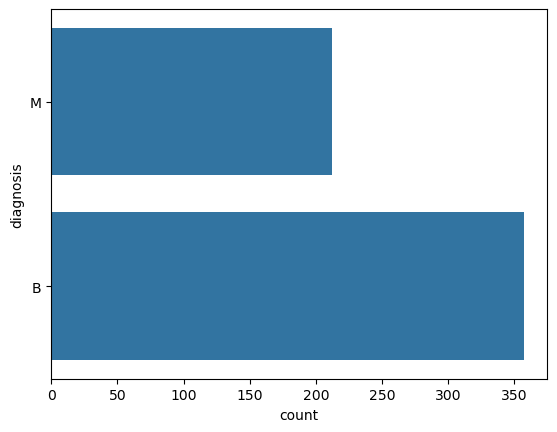

In [16]:
sns.countplot(data['diagnosis'], label='count')

In [18]:
## data type of every feature
data.dtypes

id                           int64
diagnosis                   object
radius_mean                float64
texture_mean               float64
perimeter_mean             float64
area_mean                  float64
smoothness_mean            float64
compactness_mean           float64
concavity_mean             float64
concave points_mean        float64
symmetry_mean              float64
fractal_dimension_mean     float64
radius_se                  float64
texture_se                 float64
perimeter_se               float64
area_se                    float64
smoothness_se              float64
compactness_se             float64
concavity_se               float64
concave points_se          float64
symmetry_se                float64
fractal_dimension_se       float64
radius_worst               float64
texture_worst              float64
perimeter_worst            float64
area_worst                 float64
smoothness_worst           float64
compactness_worst          float64
concavity_worst     

In [20]:
## labelencoding on diagnosis feature
from sklearn.preprocessing import LabelEncoder
labelEncoder = LabelEncoder()
data.iloc[:,1]= labelEncoder.fit_transform(data.iloc[:,1].values)

In [22]:
# map M with 1 and B with 0
print(data.iloc[:,1])

0      1
1      1
2      1
3      1
4      1
      ..
564    1
565    1
566    1
567    1
568    0
Name: diagnosis, Length: 569, dtype: object


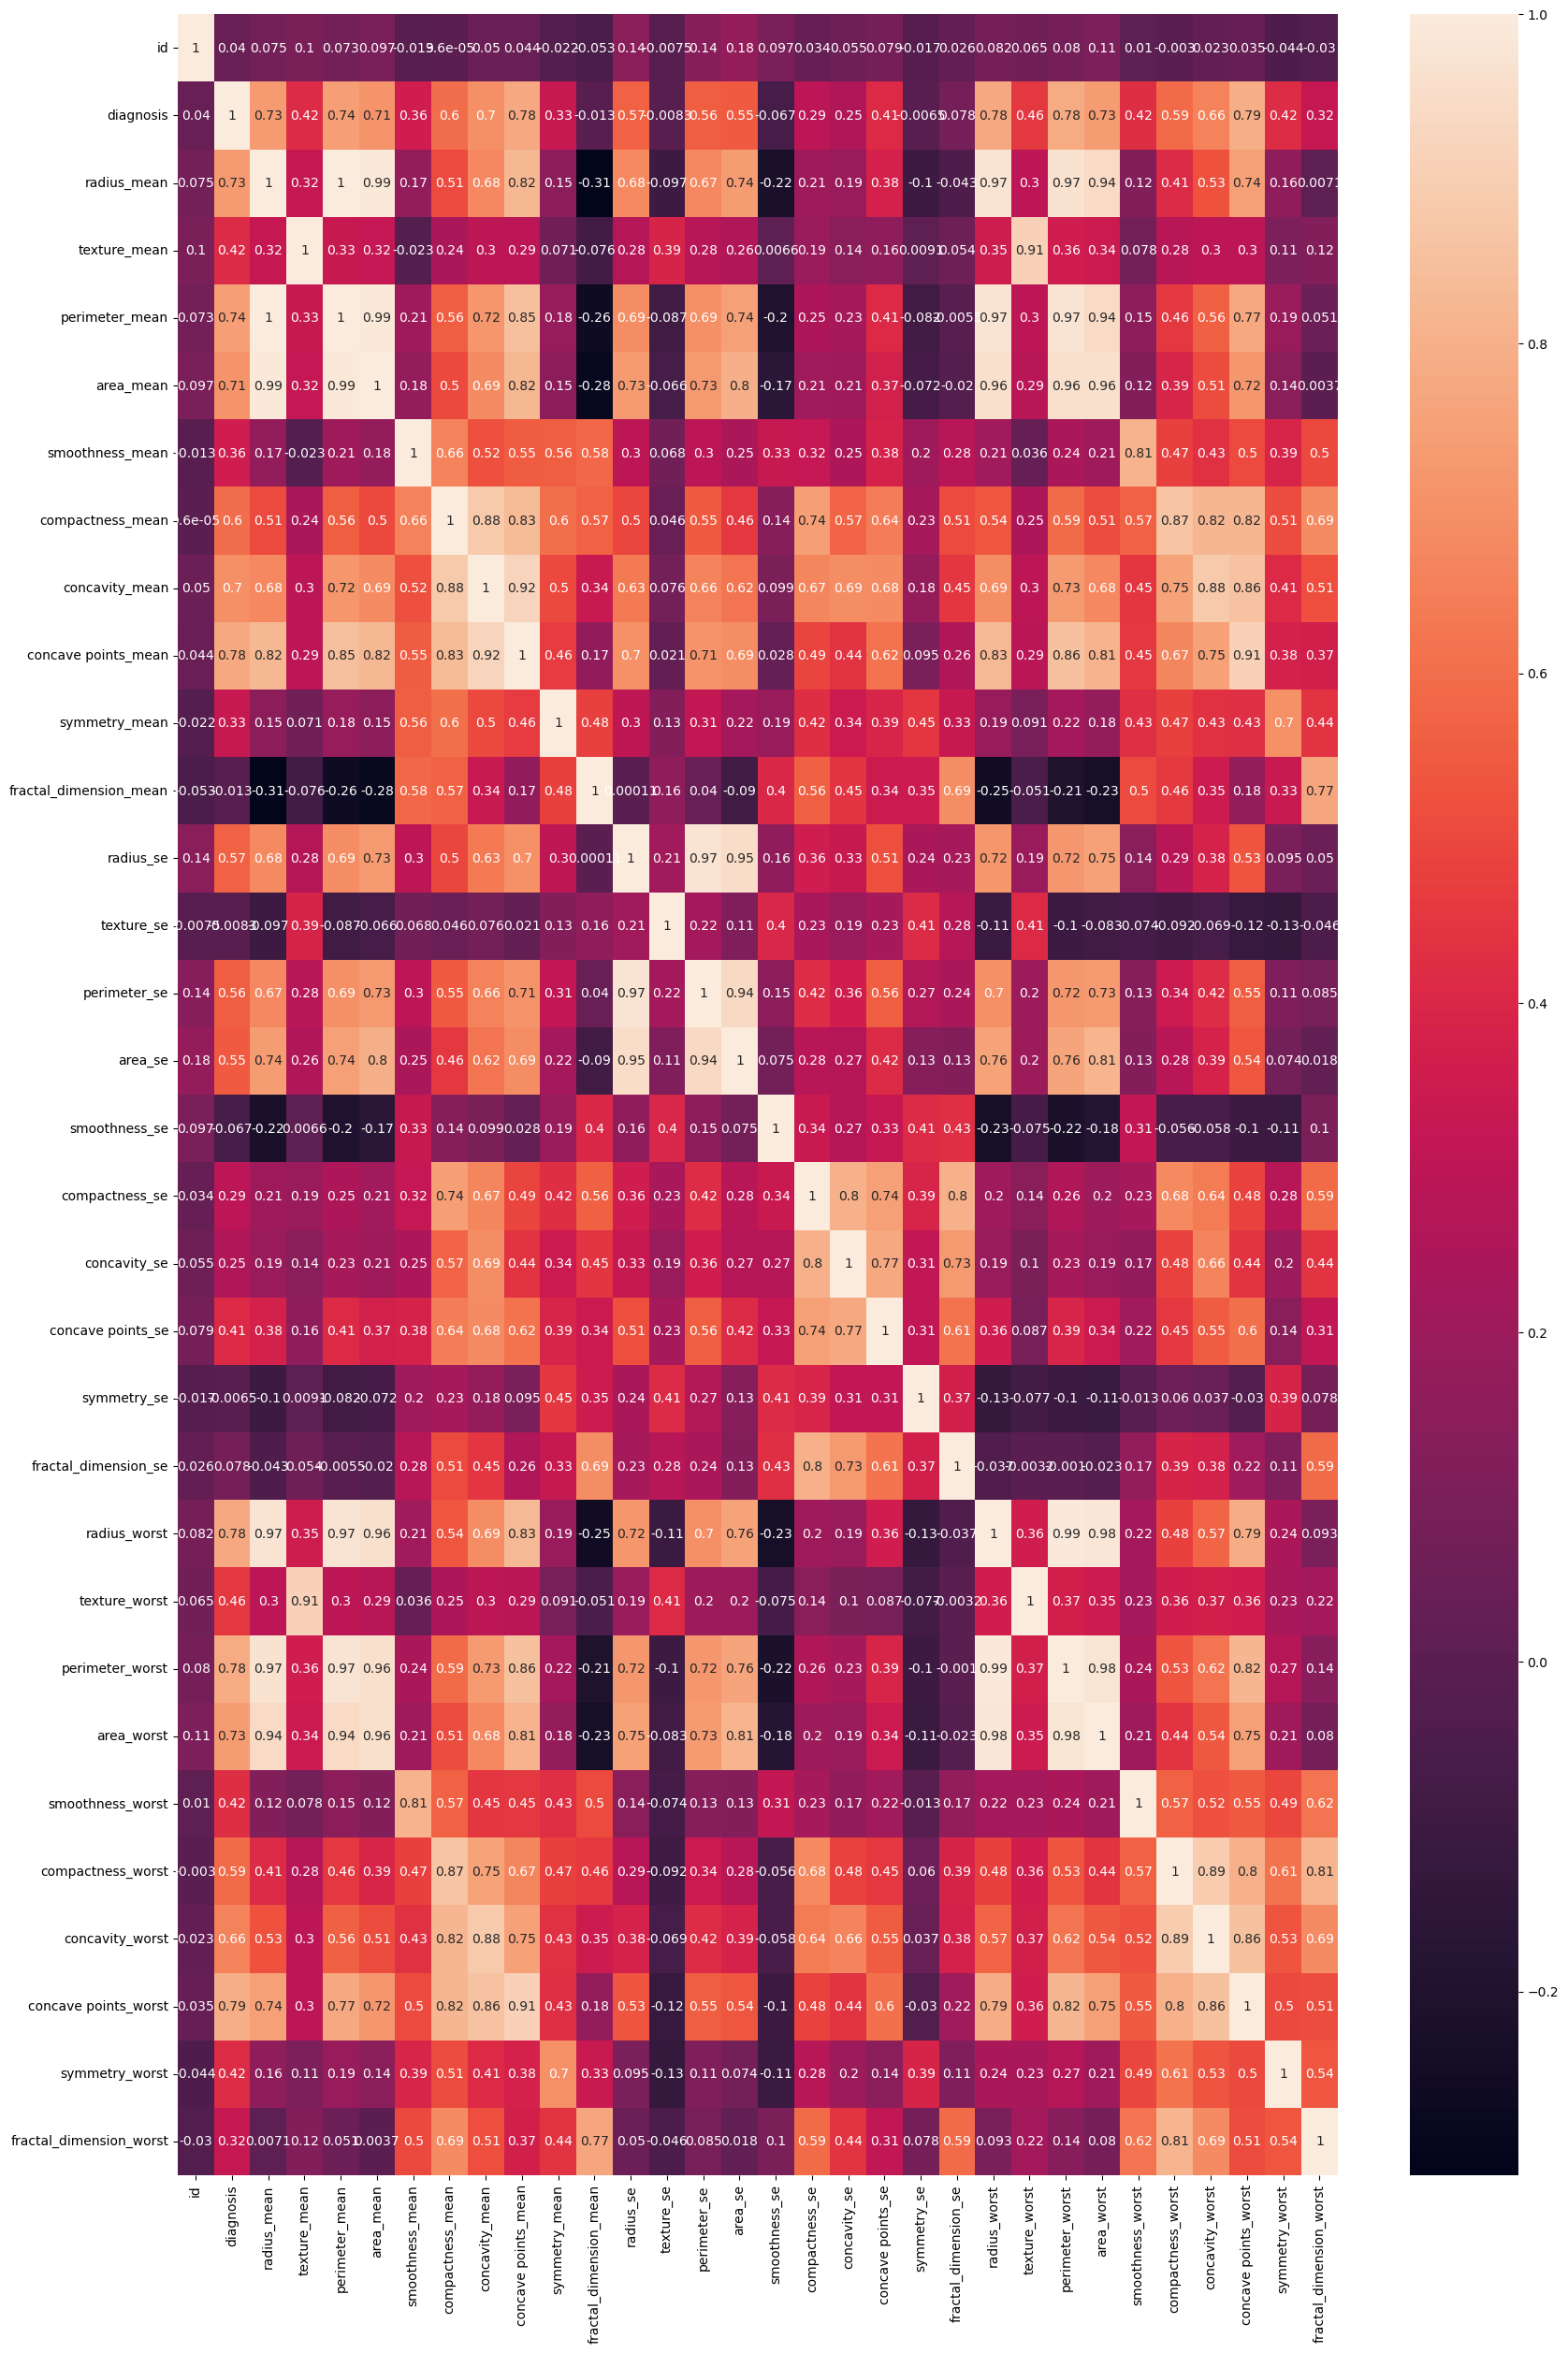

In [24]:
## correlation matrix of all features inside dataset
plt.figure(figsize=(20,30))
sns.heatmap(data.corr(),annot=True)
plt.savefig('correlation-values.png')

In [25]:
## x indicates the input feature
## y indicates the target values
x = data.iloc[:,2:31].values
y = data.iloc[:,1].values

In [26]:
## data splitting
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.25,random_state=44)

In [181]:
## scaling of all the features using standardscaler
from sklearn.preprocessing import StandardScaler
scale = StandardScaler()
x_train = scale.fit_transform(x_train)
x_test = scale.transform(x_test)

In [183]:
  ## apply multiple machine learning classification model
def models(x_train, y_train):

    ## ## train using logistic regression
    from sklearn.linear_model import LogisticRegression
    model_1 = LogisticRegression()
    model_1.fit(x_train, y_train)
    
    
    ## train using knn classifier
    from sklearn.neighbors import KNeighborsClassifier
    model_2 = KNeighborsClassifier()
    model_2.fit(x_train,y_train)

    ## train using GaussianNB classifier
    from sklearn.naive_bayes import GaussianNB
    model_3 = GaussianNB()
    model_3.fit(x_train,y_train)

    ## train using decision tree
    from sklearn.tree import DecisionTreeClassifier
    model_4 = DecisionTreeClassifier()
    model_4.fit(x_train,y_train)

    ## train using random forest
    from sklearn.ensemble import RandomForestClassifier
    model_5 = RandomForestClassifier()
    model_5.fit(x_train,y_train)

    print("Logistic Regression training accuracy", model_2.score(x_train, y_train))
    print("KNN Classifier training accuracy", model_3.score(x_train, y_train))
    print("Gaussian training accuracy", model_4.score(x_train, y_train))
    print("Decision tree Classifier training accuracy", model_5.score(x_train, y_train))
    print("Random forest Classifier training accuracy", model_6.score(x_train, y_train))

    return(model_1,model_2,model_3,model_4,model_5)

In [185]:
print(x_train.shape)
print(y_train.shape)

(426, 29)
(426,)


In [187]:
y_train  = y_train.astype(np.int64)
y_test = y_test.astype(np.int64)
print("y_train dtype:", y_train.dtype)


y_train dtype: int64


In [189]:
model = models(x_train,y_train)

Logistic Regression training accuracy 0.9812206572769953
KNN Classifier training accuracy 0.931924882629108
Gaussian training accuracy 1.0
Decision tree Classifier training accuracy 1.0
Random forest Classifier training accuracy 1.0


In [191]:
from sklearn.metrics import classification_report,accuracy_score

model_1, model_2, model_3, model_4, model_5= model

models_list = [model_1, model_2, model_3, model_4, model_5]
model_names = ["LogisticRegression", "KNNClassifier", "GaussianNB", "DecisionTreeClassifier", " RandomForestClassifier"]
for i in range(len(models_list)):
    print("Model:", model_names[i])
    ## print the classification report
    print(classification_report(y_test,models_list[i].predict(x_test)))
    ## print the accuracy report
    print("Accuracy:", accuracy_score(y_test,models_list[i].predict(x_test)))
    print()

Model: LogisticRegression
              precision    recall  f1-score   support

           0       0.99      0.99      0.99        95
           1       0.98      0.98      0.98        48

    accuracy                           0.99       143
   macro avg       0.98      0.98      0.98       143
weighted avg       0.99      0.99      0.99       143

Accuracy: 0.986013986013986

Model: KNNClassifier
              precision    recall  f1-score   support

           0       0.96      0.98      0.97        95
           1       0.96      0.92      0.94        48

    accuracy                           0.96       143
   macro avg       0.96      0.95      0.95       143
weighted avg       0.96      0.96      0.96       143

Accuracy: 0.958041958041958

Model: GaussianNB
              precision    recall  f1-score   support

           0       0.97      0.97      0.97        95
           1       0.94      0.94      0.94        48

    accuracy                           0.96       143
   ma

In [193]:
## pcreditions display for each mmodel
for i in range(len(model)):
    y_pred = model[i].predict(x_test)
    print(y_pred)
    print()
    print(y_test)
    print()

[1 1 0 1 0 0 0 0 1 0 1 0 1 1 0 0 0 1 1 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0
 0 0 0 0 0 1 0 0 0 0 0 0 1 0 0 0 1 0 1 1 0 0 0 0 0 0 1 0 1 1 0 1 1 1 0 1 0
 0 1 1 0 1 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 1 0 0 1 0 1 1 0 1 0 1 1 1 0 1
 1 1 1 0 0 0 0 0 0 1 0 1 1 1 1 1 0 0 1 0 0 0 0 0 0 0 0 0 0 1 1 0]

[1 1 0 1 0 0 0 0 1 0 1 0 1 1 0 0 0 1 1 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0
 0 0 0 0 0 1 0 0 0 0 0 0 1 0 0 0 1 0 1 1 0 0 0 0 0 0 1 0 1 1 0 1 1 1 0 1 0
 0 1 1 0 1 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 1 0 0 1 0 1 1 0 1 0 1 1 1 0 1
 1 1 1 0 0 0 0 0 1 1 0 1 1 1 1 1 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0]

[1 1 0 1 0 0 0 0 1 0 0 0 1 1 0 0 0 1 1 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0
 0 0 0 0 0 1 0 0 0 0 0 0 1 0 0 0 1 0 1 0 0 0 0 0 0 0 1 0 1 1 0 1 1 1 0 1 0
 0 1 1 0 1 0 0 0 0 0 0 1 0 0 0 1 1 0 0 0 0 0 1 0 0 1 0 1 1 0 1 0 1 1 1 0 1
 1 1 1 0 0 0 0 0 0 1 0 0 1 1 1 1 0 0 1 0 0 0 1 0 0 0 0 0 0 1 0 0]

[1 1 0 1 0 0 0 0 1 0 1 0 1 1 0 0 0 1 1 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0
 0 0 0 0 0 1 0 0 0 0 0 0 1 0 0 0 1 0 1 1 0 0 0 0 